# Florida traffic (AADT) panel — investigating `traffic preprocess` / `traffic assemble`

This notebook **imports** `src/regions/florida/sources/traffic/{preprocess,assemble}.py`
— the way `schools.ipynb`/`assessments.ipynb` do — runs each stage, and walks
through the main data-preparation decisions with the real fetched data
(57 FGDL `rciroads` releases, `jun04`→`jul26`, already on disk). Full design
brief: [`docs/data/florida/traffic/README.md`](../../../docs/data/florida/traffic/README.md).

| file | grain | written by |
|---|---|---|
| `processed/aadt_panel.parquet` | one row per `roadway_id × release_year` | `preprocess` |
| `assembled/school_road_match.parquet` | one row per placed `msid` | `assemble` |
| `assembled/school_aadt_panel.parquet` | one row per `msid × release_year` | `assemble` |

Three decisions drove this source's design, and each gets its own section
below with the real data behind it: (1) why the panel grain is
`roadway_id × release_year`, not `roadway_id × segmentid` — FGDL re-segments
each roadway release to release; (2) why AADT is aggregated as a
length-weighted mean, not a plain mean; (3) a real bug found mid-build
(grouping by `version` silently split a calendar year with several releases
back into duplicate rows) and its fix. §7 also re-derives, live, the
2003–2010 vs. 2014+ panel-match-rate investigation from
`docs/data/florida/traffic/README.md`.

Final-panel-level descriptives (match-rate-by-year plots, `aadt_local`
distributions) live in
[`output/notebooks/descriptive_statistics.ipynb`](../../../output/notebooks/florida/descriptive_statistics.ipynb)
§8 — this notebook stays focused on *why* the source is built the way it is.

Run with the `311` conda env (geopandas, pandas 3).

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110
BLUE, RED, GREEN, ORANGE, GREY = "#4C78A8", "#E45756", "#1f6f3f", "#d9822b", "#B0B0B0"


def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.regions.florida.sources.traffic import preprocess as PRE              # noqa: E402
from src.regions.florida.sources.traffic import assemble as ASM                # noqa: E402
from src.regions.florida.sources.traffic import shared as SH                   # noqa: E402

FIGDIR = ROOT / "output/figures/florida"
FIGDIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, bbox_inches="tight", dpi=130)
    print("  saved", path.relative_to(ROOT))


ROOT

PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution')

## 1. Why the panel grain is `roadway_id × release_year`, not `roadway_id × segmentid`

The original design matched `road_network.parquet`'s own grain
(`roadway_id × segmentid`) — checked against two real releases before
committing to it.

In [2]:
jul26 = pd.read_parquet(SH.raw_aadt_path("jul26", ROOT))
jan19 = pd.read_parquet(SH.raw_aadt_path("jan19", ROOT))

jul26_pairs = set(zip(jul26["roadway_id"], jul26["segmentid"]))
jan19_pairs = set(zip(jan19["roadway_id"], jan19["segmentid"]))
shared_pairs = jul26_pairs & jan19_pairs

jul26_roadways = set(jul26["roadway_id"])
jan19_roadways = set(jan19["roadway_id"])
shared_roadways = jul26_roadways & jan19_roadways

print(f"jul26: {len(jul26):,} segments, {len(jul26_roadways):,} distinct roadway_ids")
print(f"jan19: {len(jan19):,} segments, {len(jan19_roadways):,} distinct roadway_ids")
print(f"(roadway_id, segmentid) pairs shared jul26<->jan19: {len(shared_pairs):,} of {len(jul26_pairs):,}")
print(f"roadway_id alone shared jul26<->jan19:              {len(shared_roadways):,} "
      f"({len(shared_roadways) / len(jul26_roadways):.0%} of jul26's roadways)")

jul26: 40,357 segments, 18,373 distinct roadway_ids
jan19: 26,595 segments, 15,591 distinct roadway_ids
(roadway_id, segmentid) pairs shared jul26<->jan19: 5 of 40,357
roadway_id alone shared jul26<->jan19:              15,471 (84% of jul26's roadways)


`segmentid` (and even `begin_post`/`end_post` breakpoints for the same
physical stretch) is **not** stable across FGDL releases — FGDL re-segments
each `ROADWAY` differently release to release. `roadway_id` itself, by
contrast, is stable. So `preprocess.py` collapses every release's segments
within a `roadway_id` into one row per `roadway_id × release_year`, rather
than trying to track a segment across releases.

## 2. Length-weighted aggregation, not a plain segment mean

In [3]:
segments = PRE._clean_segments(jul26)
multi = segments.groupby("roadway_id").filter(lambda g: len(g) > 1)
# pick the roadway with the largest length-weighted vs. plain-mean divergence
diffs = []
for rid, g in multi.groupby("roadway_id"):
    weighted = PRE._weighted_mean_aadt(g)
    plain = g.loc[g["aadt"] > 0, "aadt"].mean()
    if pd.notna(weighted) and pd.notna(plain) and plain > 0:
        diffs.append((rid, len(g), weighted, plain, abs(weighted - plain) / plain))
diffs.sort(key=lambda t: -t[4])
rid, n_seg, weighted, plain, pct_diff = diffs[0]

example = segments[segments["roadway_id"] == rid][["segmentid", "begin_post", "end_post", "aadt"]]
example = example.assign(length_mi=(example["end_post"] - example["begin_post"]).clip(lower=PRE.MIN_SEGMENT_LENGTH_MI))
print(f"roadway_id {rid}: {n_seg} segments")
print(example.to_string(index=False))
print(f"\nlength-weighted mean AADT: {weighted:,.0f}")
print(f"plain segment mean AADT:   {plain:,.0f}  ({pct_diff:.0%} different)")

roadway_id 72040332: 4 segments
 segmentid  begin_post  end_post   aadt  length_mi
     21204       0.000     0.102  150.0      0.102
     21205       0.102     1.855 2200.0      1.753
     21206       1.855     1.906  150.0      0.051
     21207       1.906     2.028  150.0      0.122

length-weighted mean AADT: 1,922
plain segment mean AADT:   662  (190% different)


A roadway carrying high AADT for most of its length and low AADT for a
short spur should average closer to the high value than a plain per-segment
mean would give it credit for — `_weighted_mean_aadt` weights by
`end_post - begin_post` (segment length in miles) for exactly this reason.

## 3. Fixed bug: grouping by `version` silently split a multi-release year into duplicate rows

FGDL releases 3–4×/year since 2016 (e.g. `jan26`/`apr26`/`jul26` all map to
`release_year=2026`). The original aggregation grouped by
`[roadway_id, release_year, version]` — which, since `version` determines
`release_year`, was really grouping by `version` alone, producing 2–4
duplicate rows per true `(roadway_id, release_year)` group.

In [4]:
raw = PRE.load_raw_traffic_tables()
processed = PRE.preprocess_traffic(raw)

release_counts = processed["release_count"].value_counts().sort_index()
print("release_count distribution across the fixed aadt_panel.parquet (1 = single release that year):")
print(release_counts)
n_pooled = (processed["release_count"] > 1).sum()
pct_pooled = (processed["release_count"] > 1).mean()
print(f"\n{n_pooled:,} of {len(processed):,} roadway-year rows ({pct_pooled:.1%}) "
      "pool >=2 FGDL releases into one length-weighted mean.")

release_count distribution across the fixed aadt_panel.parquet (1 = single release that year):
release_count
1     40750
2     13721
3     62877
4    155308
Name: count, dtype: int64

231,906 of 272,656 roadway-year rows (85.1%) pool >=2 FGDL releases into one length-weighted mean.


`release_count` (how many distinct FGDL versions contributed to a row) is
kept as a diagnostic precisely because of this history — a consumer can see
how much pooling happened, not just trust a silently-deduplicated number.
See `preprocess.py`'s module docstring for the full incident writeup
(85% of roadway-year groups were affected before the fix).

## 4. Run the full `preprocess` (validates + persists)

In [5]:
report = PRE.run_traffic_preprocess()
print(json.dumps({k: v for k, v in report.items() if k not in ("saved",)}, indent=1, default=str))
for k, v in report["saved"].items():
    print("wrote", Path(v).relative_to(ROOT))

{
 "raw_rows": 1737028,
 "rows": 272656,
 "distinct_roadway_ids": 20262,
 "release_years": [
  2004,
  2006,
  2007,
  2008,
  2009,
  2010,
  2011,
  2016,
  2017,
  2018,
  2019,
  2020,
  2021,
  2022,
  2023,
  2024,
  2025,
  2026
 ],
 "versions": [
  "apr06",
  "apr07",
  "apr08",
  "apr09",
  "apr16",
  "apr17",
  "apr18",
  "apr19",
  "apr20",
  "apr21",
  "apr22",
  "apr23",
  "apr24",
  "apr25",
  "apr26",
  "feb10",
  "feb11",
  "jan07",
  "jan08",
  "jan09",
  "jan18",
  "jan19",
  "jan20",
  "jan21",
  "jan22",
  "jan23",
  "jan24",
  "jan25",
  "jan26",
  "jul06",
  "jul07",
  "jul09",
  "jul16",
  "jul17",
  "jul18",
  "jul19",
  "jul20",
  "jul21",
  "jul22",
  "jul23",
  "jul24",
  "jul25",
  "jul26",
  "jun04",
  "oct06",
  "oct07",
  "oct09",
  "oct16",
  "oct17",
  "oct18",
  "oct19",
  "oct20",
  "oct21",
  "oct22",
  "oct23",
  "oct24",
  "oct25"
 ],
 "aadt_known": 142301,
 "columns": [
  "roadway_id",
  "release_year",
  "release_count",
  "aadt",
  "aadt_min",
 

## 5. School↔roadway matching + local-intensity scaling (`assemble`)

`assemble.py` matches each placed school to its nearest arterial
`roadway_id` (reusing `road_network/linear_ref.py`'s spatial join), then
computes a **local-intensity ratio**: the matched segment's own AADT
(available for one snapshot only, `road_network.parquet`) divided by that
roadway's `aadt_panel` mean for the same release year. Applying that ratio
to every release year's roadway mean gives `aadt_local` — a school-specific
estimate that doesn't require true segment-level history (which isn't
available, per §1).

placed schools: 5,984 | matched to a roadway: 5,366 (89.7%)
reference snapshot: jul26 (release_year=2026)


  saved output/figures/florida/traffic_school_road_dist_hist.png


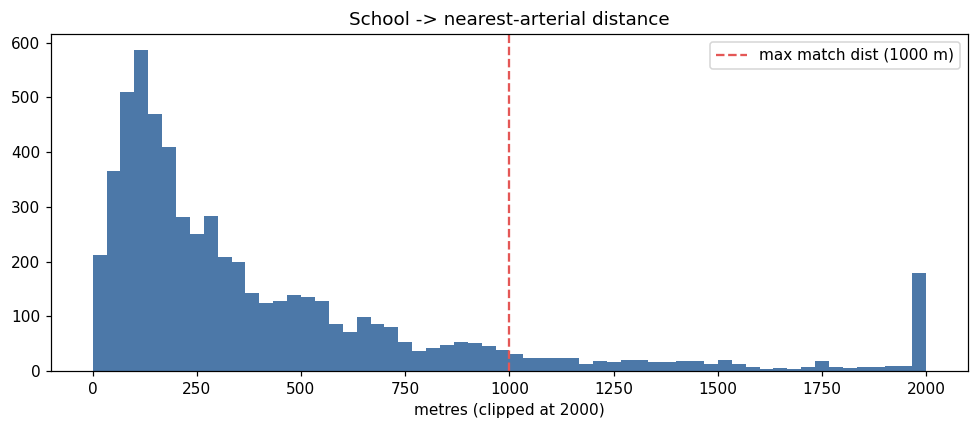

In [6]:
placed = ASM.load_placed_schools(ROOT)
road_network = ASM.load_road_network(ROOT)
aadt_panel = ASM.load_aadt_panel(ROOT)
reference_version = ASM.load_road_network_reference_version(ROOT)
reference_release_year = SH.release_year(reference_version)

school_road_match = ASM.match_schools_to_roadway(placed, road_network)
school_road_match = ASM.compute_local_intensity(school_road_match, aadt_panel, reference_release_year)

matched = school_road_match["roadway_id"].notna()
print(f"placed schools: {len(placed):,} | matched to a roadway: {matched.sum():,} ({matched.mean():.1%})")
print(f"reference snapshot: {reference_version} (release_year={reference_release_year})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(school_road_match["dist_m"].clip(upper=2000), bins=60, color=BLUE)
ax.axvline(ASM.MAX_MATCH_DIST_M, color=RED, linestyle="--", label=f"max match dist ({ASM.MAX_MATCH_DIST_M:.0f} m)")
ax.set_title("School -> nearest-arterial distance")
ax.set_xlabel("metres (clipped at 2000)")
ax.legend()
fig.tight_layout()
savefig(fig, "traffic_school_road_dist_hist.png")
plt.show()

In [7]:
ratio = school_road_match["local_intensity_ratio"].dropna()
frac_gt_1_5x = (ratio.sub(1).abs() > 0.5).mean()
frac_gt_2x = ((ratio > 2) | (ratio < 0.5)).mean()
print(f"schools with a local-intensity ratio: {len(ratio):,} of {matched.sum():,} matched")
print(f"ratio >1.5x or <1/1.5x roadway average: {frac_gt_1_5x:.1%}")
print(f"ratio >2x or <0.5x roadway average:     {frac_gt_2x:.1%}")
print(ratio.describe())

schools with a local-intensity ratio: 5,361 of 5,366 matched
ratio >1.5x or <1/1.5x roadway average: 12.5%
ratio >2x or <0.5x roadway average:     6.1%
count    5361.000000
mean        1.084149
std         0.388020
min         0.070626
25%         0.934798
50%         1.004785
75%         1.170062
max         3.915301
Name: local_intensity_ratio, dtype: float64


A real, moderate minority of schools sit on a stretch of their matched
roadway that is meaningfully busier or quieter than the roadway-wide
average — this is exactly the gap `aadt_local` is meant to narrow. It is a
**deliberate approximation, not true history**: it assumes a school's
position *relative to* its roadway's own average is stable over time (a
weaker assumption than assuming the roadway-wide level itself is stable),
anchored to one snapshot only since segment identity doesn't survive across
releases (§1).

## 6. Run the full `assemble` (validates + persists)

In [8]:
report = ASM.run_traffic_assemble(root=ROOT)
print(json.dumps({k: v for k, v in report.items() if k not in ("saved",)}, indent=1, default=str))
for k, v in report["saved"].items():
    print("wrote", Path(v).relative_to(ROOT))

{
 "generated_at_utc": "2026-09-14T14:38:51+00:00",
 "generated_by": "src/regions/florida/sources/traffic/assemble.py",
 "max_dist_m": 1000.0,
 "reference_version": "jul26",
 "reference_release_year": 2026,
 "schools_placed": 5984,
 "schools_matched": 5366,
 "schools_unmatched": 618,
 "schools_with_local_intensity_ratio": 5361,
 "school_aadt_panel_rows": 91431,
 "aadt_known_rows": 78455,
 "aadt_local_known_rows": 78455
}
wrote data/florida/traffic/assembled/school_road_match.parquet
wrote data/florida/traffic/assembled/school_aadt_panel.parquet


## 7. The panel-level match-rate gap (2003–2010 vs. 2014+) — root cause, re-derived live

The final event-study panel's `traffic_aadt` match rate steps from ~46%
(2003–2010) to ~58% (2011–2013) to ~82%+ (2014 on). The original suspicion
(older/closed schools disproportionately unmatched to a roadway) turned out
to be wrong — `school_road_match` above is msid-level and year-invariant.
The real driver is on the roadway side: how much of `rciroads`' `AADT`
field was actually populated, release by release.

  saved output/figures/florida/traffic_aadt_field_coverage_by_release.png


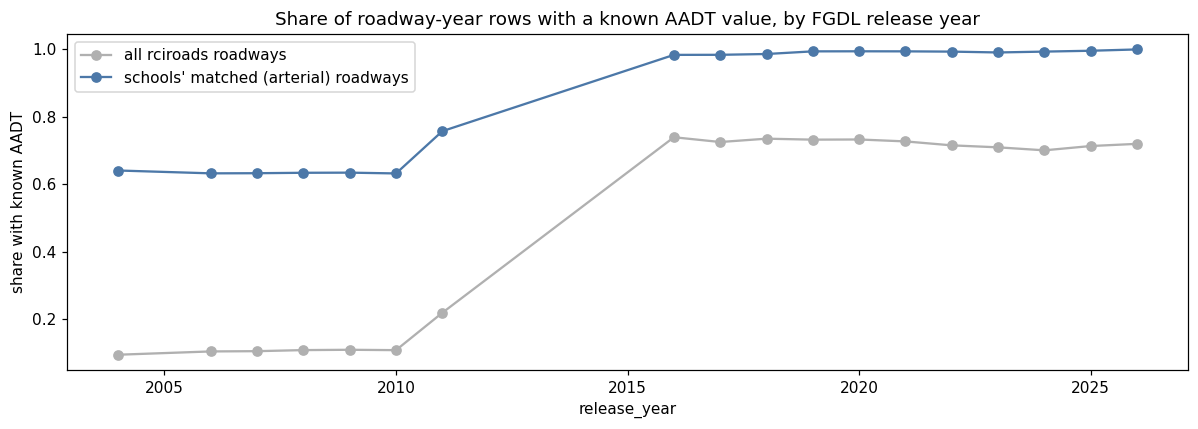

all roadways, 2004-2010 avg coverage:   10.4%
all roadways, 2016+ avg coverage:       72.2%
schools' roadways, 2004-2010 avg:       63.4%
schools' roadways, 2016+ avg:           99.1%


In [9]:
aadt_panel = pd.read_parquet(SH.processed_aadt_panel_path(ROOT))
all_roadway_coverage = aadt_panel.groupby("release_year").apply(
    lambda g: g["aadt"].notna().mean()
)

school_aadt_panel = pd.read_parquet(SH.school_aadt_panel_path(ROOT))
school_roadway_coverage = (
    school_aadt_panel.dropna(subset=["release_year"])
    .groupby("release_year")["aadt"]
    .apply(lambda s: s.notna().mean())
)

fig, ax = plt.subplots(figsize=(11, 4))
all_roadway_coverage.plot(ax=ax, marker="o", color=GREY, label="all rciroads roadways")
school_roadway_coverage.plot(ax=ax, marker="o", color=BLUE, label="schools\' matched (arterial) roadways")
ax.set_title("Share of roadway-year rows with a known AADT value, by FGDL release year")
ax.set_xlabel("release_year")
ax.set_ylabel("share with known AADT")
ax.legend()
fig.tight_layout()
savefig(fig, "traffic_aadt_field_coverage_by_release.png")
plt.show()

print("all roadways, 2004-2010 avg coverage:  ", f"{all_roadway_coverage.loc[2004:2010].mean():.1%}")
print("all roadways, 2016+ avg coverage:      ", f"{all_roadway_coverage.loc[2016:].mean():.1%}")
print("schools\' roadways, 2004-2010 avg:      ", f"{school_roadway_coverage.loc[2004:2010].mean():.1%}")
print("schools\' roadways, 2016+ avg:          ", f"{school_roadway_coverage.loc[2016:].mean():.1%}")

Comprehensive AADT counting for arterial roads simply wasn't in place
until roughly 2016 — a genuine characteristic of the underlying FDOT/FGDL
source, not a pipeline defect. Schools' matched roads track the "all
roadways" curve but sit well above it throughout, since `arterial_subset`
already restricts matching to the major/collector roads FDOT prioritizes
for counting. This fully explains the panel-level step pattern
(`docs/data/florida/traffic/README.md`'s real-run section has the full
writeup, incl. the panel-level numbers).

## Notes & next steps

- **Truck AADT / heavy-vehicle share** — not on the `rciroads` layer this
  source reads; `covariates.md` tags it `baseline` role (trucks dominate
  roadside noise), so it would need a separate FDOT Truck AADT layer or
  `FTI.mdb` — not investigated.
- **Pre-`jun04` coverage** — some walls have `built_year` in the 1990s;
  `rciroads`' archive starts `jun04`. Not resolved — same posture
  `road_network` already took toward its own pre-2004 gap (one proxy
  snapshot, not diffed across releases further back).
- **Selection concern for the FCAT era** — where `traffic_aadt` *is* present
  pre-2016 (§7), it may reflect which roads FDOT happened to count first
  rather than a representative sample of arterials; worth a robustness
  check restricting to 2016+ if pre-2016 `traffic_aadt` estimates look
  fragile.